<a href="https://colab.research.google.com/github/hanimnzra/Data-Visualisation/blob/main/titanic_visualisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛳️ Titanic Dataset Visualisations

**Date:** 27 October 2025  

---

### 📘 Description
This notebook visualises the Titanic dataset (`train.csv`).

**Tools & Libraries:**
- Python 3  
- pandas (for data manipulation)  
- matplotlib
- Google Colab environment  

**Dataset Info:**  
The dataset contains information about Titanic passengers such as name, age, gender, class, fare, and survival status.


Import needed libraries

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Upload CSV file

In [34]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train (1).csv


Load file to read

In [35]:
df = pd.read_csv("train.csv")

In [36]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

1. Missing values in "Age", "Cabin", "Embarked"

In [37]:
df["Age"].isna().sum()

np.int64(177)

In [38]:
df["Cabin"].isna().sum()

np.int64(687)

In [39]:
df["Embarked"].isna().sum()

np.int64(2)

> There are 177 missing values in "Age", 687 missing in "Cabin", and 2 missing in "Embarked".



2. Pie chart for percentage of passengers that embarked from
each port (Southampton, Cherbourg, Queenstown)

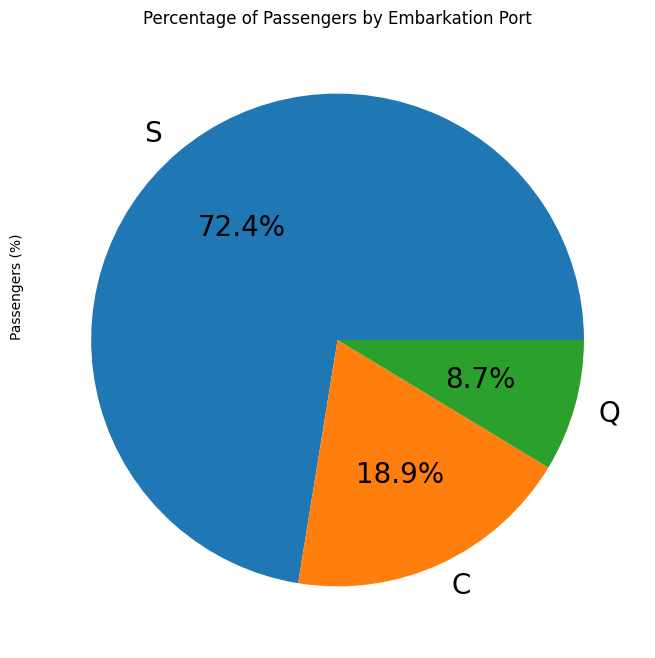

In [40]:
total_passenger = df["Embarked"].dropna().value_counts()
percentage_passenger = (total_passenger / total_passenger.sum()) * 100

# Plot pie chart
percentage_passenger.plot(kind='pie', autopct='%1.1f%%', fontsize=20, figsize=(8, 8))
plt.ylabel('Passengers (%)', horizontalalignment='left')
plt.title('Percentage of Passengers by Embarkation Port')
plt.show()

> Most of the passengers embarked from Southampton (72.4%), while the least amount of passengers embarked from Queenstown (8.7%)

3. Bar chart for passengers in each class

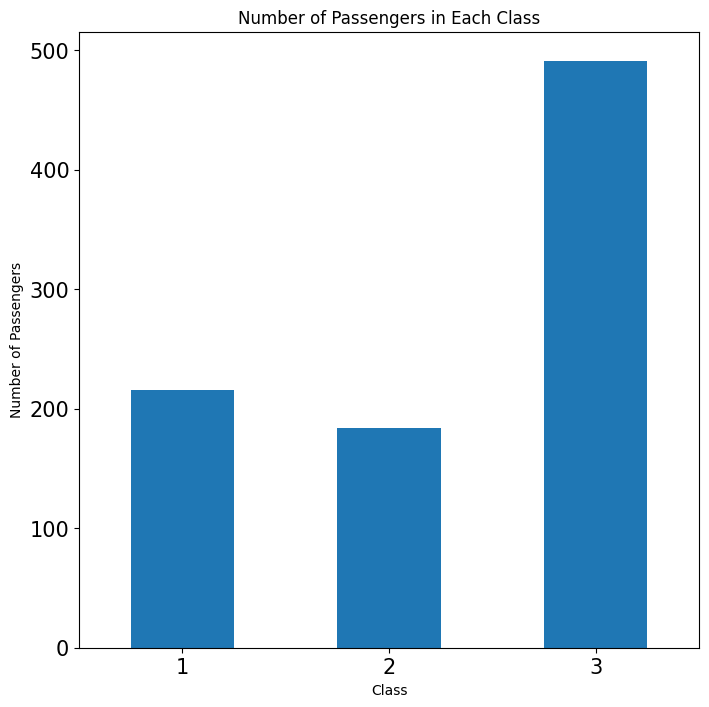

In [41]:
class_count = df['Pclass'].dropna().value_counts().sort_index()

# Plot bar chart
class_count.plot(kind='bar', fontsize=15, rot=0, figsize=(8, 8))
plt.xlabel('Class')
plt.ylabel('Number of Passengers')
plt.title('Number of Passengers in Each Class')
plt.show()

> Most passengers are of class 3 (nearly 500).

4. Bar chart for number of female passengers for each class (survived vs not)

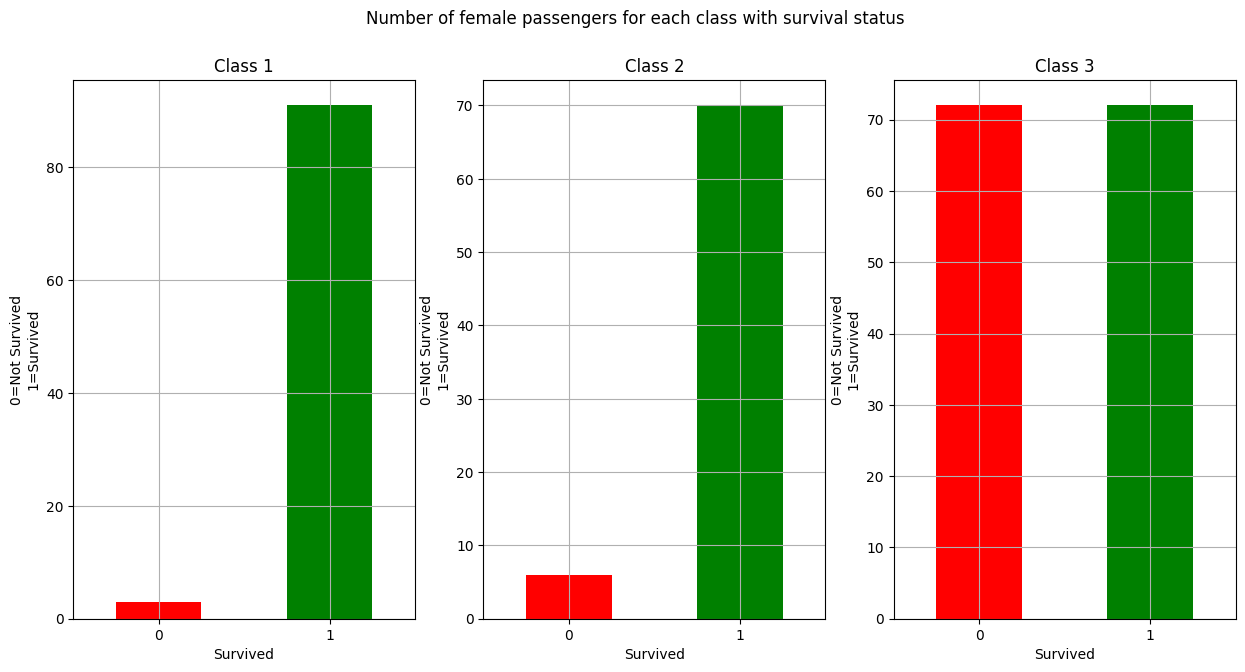

In [42]:
# ==============
# First version
# ==============
# female_class = df[df['Sex']=='female'].groupby(['Pclass', 'Survived']).size().unstack().fillna(0)

# # Plot bar chart
# female_class.plot(kind='bar', fontsize=15, rot=0, figsize=(8, 8))
# plt.xlabel('Class')
# plt.ylabel('Number of Female Passengers')
# plt.title('Number of Female Passengers by Class and Survival State')
# plt.legend(['Not Survived', 'Survived'], title='Survived')
# plt.show()

# ==============
# Second version
# ==============
# female_class_survival = df[df['Sex'] == 'female'].groupby(['Pclass', 'Survived']).size().unstack().fillna(0)

# for pclass in female_class_survival.index:
#     female_class_survival.loc[pclass].plot(kind='bar', color=["red", "green"], fontsize=15, rot=0, figsize=(6, 6))
#     plt.xlabel('Survival Status')
#     plt.ylabel('Number of Female Passengers')
#     plt.title(f'Female Passengers in Class {pclass} by Survival State')
#     plt.xticks([0, 1], ['Not Survived', 'Survived'], rotation=0)
#     plt.show()

# ==============
# Third version
# ==============
plt.figure(figsize=(15,7)) #sets the figure size
plt.suptitle("Number of female passengers for each class with survival status") #sets the title

for n in range(3):
  plt.subplot(1,3,n+1)
  #shows the number of female passengers for class 1 who survived and who did not survive
  df[(df["Pclass"]==n+1) & (df["Sex"]=="female")].groupby("Survived").size().plot(kind="bar", title=f"Class {n+1}", ylabel='0=Not Survived\n1=Survived', color=["red","green"], rot=0)
  plt.grid() #shows the grid
plt.show()

5. Boxplots for key age statistics of female and male
passengers who survived and who did not survive.

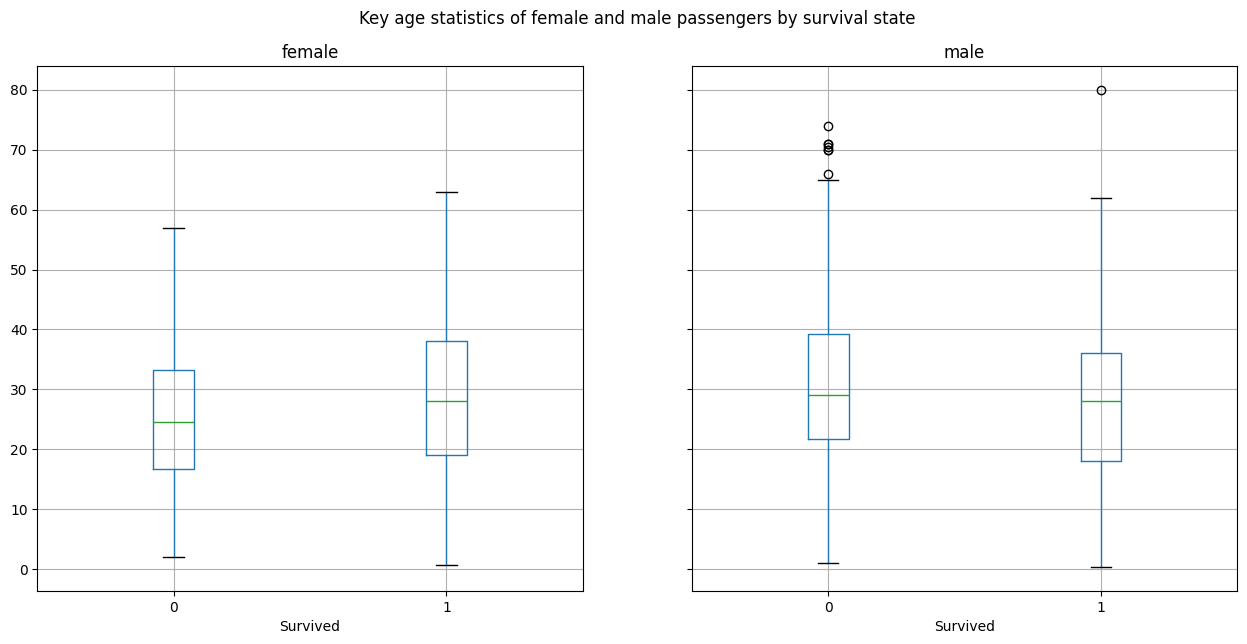

In [43]:
df2 = df.dropna(subset=["Age"])
df2.groupby('Sex').boxplot(column='Age', by='Survived', figsize=(15, 7))
plt.suptitle("Key age statistics of female and male passengers by survival state")

plt.show()

6. Cross table for passenger count by sex and survival status.

In [44]:
pd.crosstab(df['Sex'], df['Survived'], margins=True)

Survived,0,1,All
Sex,,,
female,81,233,314
male,468,109,577
All,549,342,891


7. Heatmap for correlation between attributes (Survived, Age, Sex, Fare, Class).

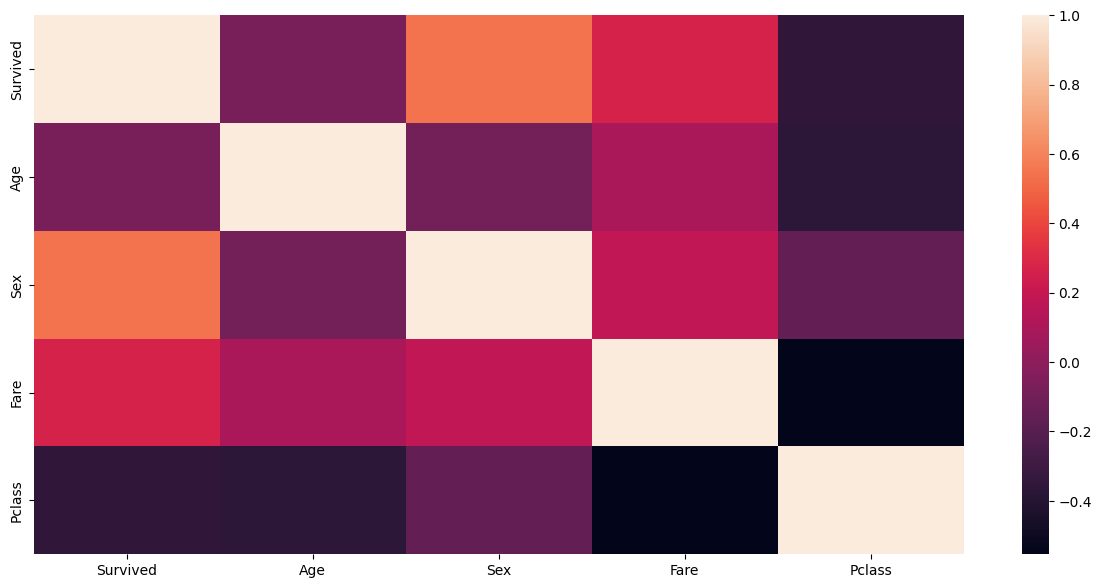

In [49]:
df3 = pd.DataFrame(df, columns=['Survived', 'Age', 'Sex', 'Fare', 'Pclass'])
df3 = df3.dropna()

df3['Sex'] = df3['Sex'].map({'male': 0, 'female': 1})

fig, ax = plt.subplots(figsize=(15, 7))
sns.heatmap(df3.corr())
plt.show()

8. Pearson standard correlation coefficient for each correlation in Q7. How is survival correlated to ticket class?

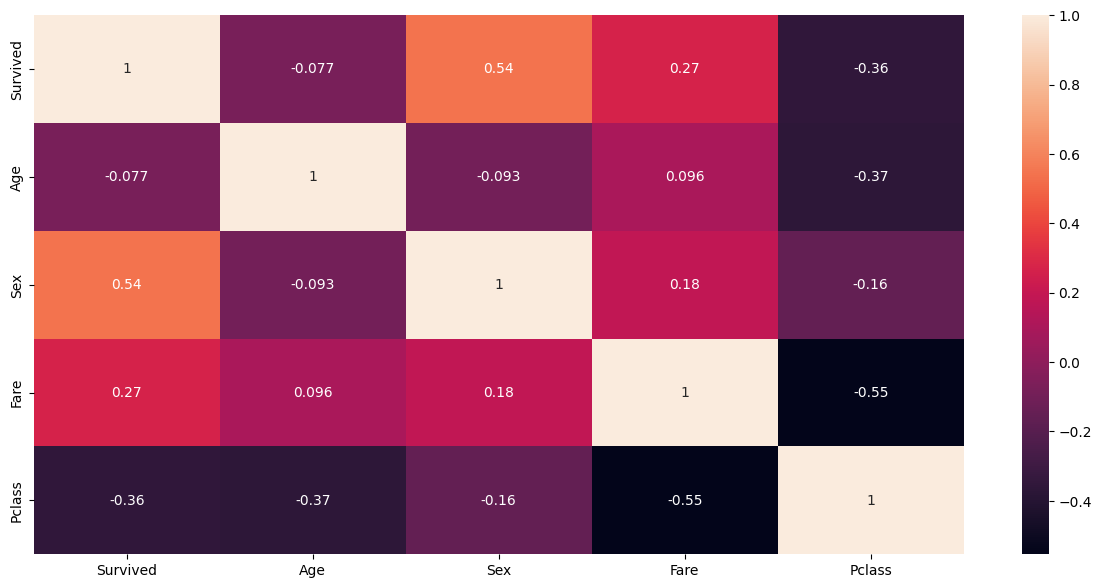

In [51]:
fig, ax = plt.subplots(figsize=(15, 7))
sns.heatmap(df3.corr(), annot=True)
plt.show()

> The correlation between Survived and Pclass is negative, at -0.36. This means that there is an inverse relationship between survived and ticket class, where if one variable increases, the other decreases. In other words, the higher the ticket class (in numbers), the lower chance of survivng. Passengers travelling in first class will have higher possibility of surviving than in second class, which is also relatively higher the the third class ticket.

9. Histograms for the age distribution of the female and male passengers who survived.

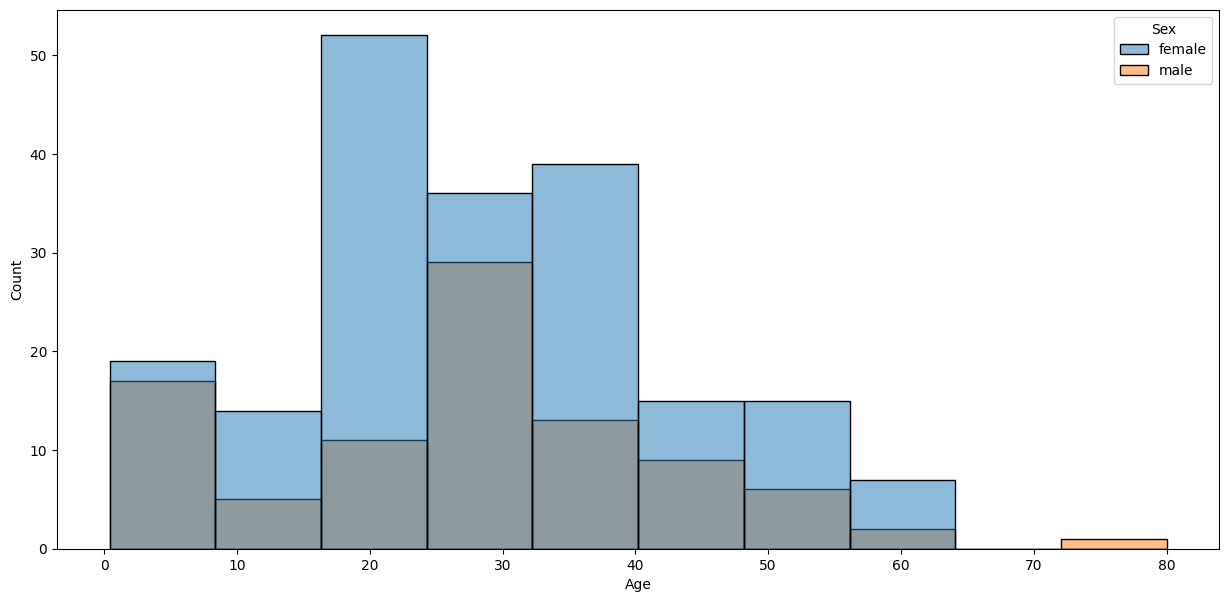

In [59]:
fig, ax = plt.subplots(figsize=(15,7))
sns.histplot(data=df2.loc[df2['Survived']==1], bins=10, x='Age', hue='Sex')
plt.show()

10. Scatterplot for the age-fare correlation for passengers who
survived and who did not survive.

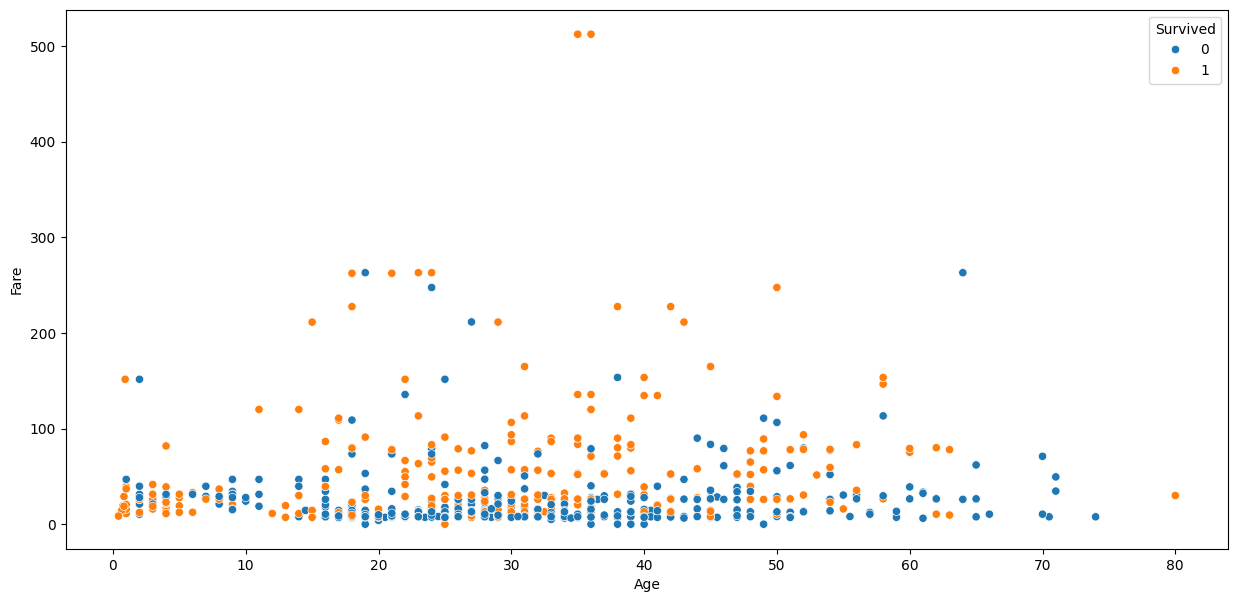

In [61]:
fig, ax = plt.subplots(figsize=(15, 7))
sns.scatterplot(data=df2, x='Age', y='Fare', hue='Survived', ax=ax)
plt.show()